Intercept: -117.70550915658714
Coefficient: 2.232907473785875
R^2 score: 0.33502238235153126


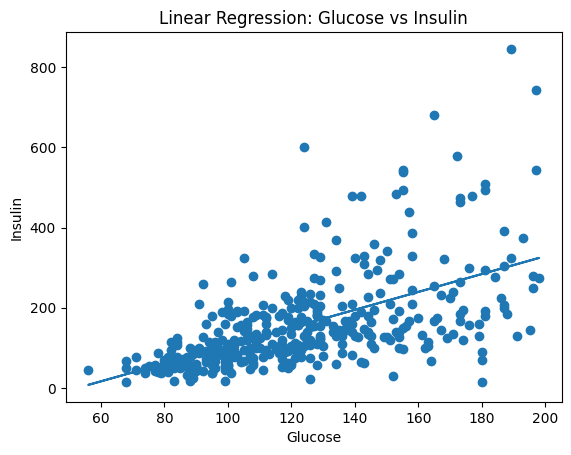

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv(r"C:\Users\Nurik\Downloads\diabetes[1].csv", sep=';')

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Keep only needed columns
df = df[['Glucose', 'Insulin']]

# Remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Remove entire rows where Glucose = 0 or Insulin = 0
df = df[(df['Glucose'] != 0) & (df['Insulin'] != 0)]

# Define X and y
X = df[['Glucose']]
y = df['Insulin']

# Train linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Output results
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R^2 score:", model.score(X, y))

# Plot
plt.scatter(df['Glucose'], df['Insulin'])
plt.plot(df['Glucose'], y_pred)
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.title("Linear Regression: Glucose vs Insulin")
plt.show()

Mean of Glucose: 123.14792899408285
Mean of Insulin: 120.26232741617358
Intercept: -38.321240152045874
Coefficient: 1.5071649781114405
R^2 score: 0.21788841360895428


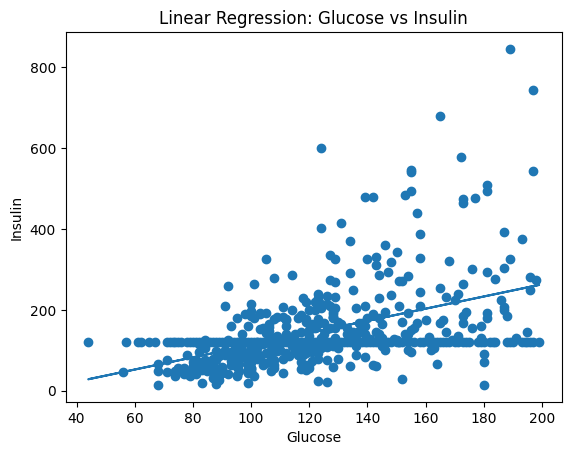

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv(r"C:\Users\Nurik\Downloads\diabetes[1].csv", sep=';')

# Remove extra spaces in column names
df.columns = df.columns.str.strip()

# Keep only needed columns
df = df[['Glucose', 'Insulin']]

# Remove missing values and duplicates
df = df.dropna()
df = df.drop_duplicates()

# Calculate mean values
glucose_mean = df['Glucose'].mean()
insulin_mean = df['Insulin'].mean()

print("Mean of Glucose:", glucose_mean)
print("Mean of Insulin:", insulin_mean)

# Replace 0 values with mean
df['Glucose'] = df['Glucose'].replace(0, glucose_mean)
df['Insulin'] = df['Insulin'].replace(0, insulin_mean)

# Define X and y
X = df[['Glucose']]
y = df['Insulin']

# Train linear regression model
model = LinearRegression()
model.fit(X, y)

# Predict values
y_pred = model.predict(X)

# Output results
print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])
print("R^2 score:", model.score(X, y))

# Plot
plt.scatter(df['Glucose'], df['Insulin'])
plt.plot(df['Glucose'], y_pred)
plt.xlabel("Glucose")
plt.ylabel("Insulin")
plt.title("Linear Regression: Glucose vs Insulin")
plt.show()

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Load dataset
df = pd.read_csv(r"C:\Users\Nurik\Downloads\diabetes.csv")

# 2. Show first rows
print("First 5 rows:")
print(df.head())

# 3. Split features and target
X = df.drop("Outcome", axis=1)   # input data
y = df["Outcome"]                # target

# 4. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 5. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Create SVM classifier
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)

# 7. Train model
svm_model.fit(X_train_scaled, y_train)

# 8. Predict
y_pred = svm_model.predict(X_test_scaled)

# 9. Evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Accuracy: 0.7532467532467533

Confusion Matrix:
[[83 17]
 [21 33]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       100
           1       0.66      0.61      0.63        54

    accuracy                     

Accuracy: 0.7532467532467533


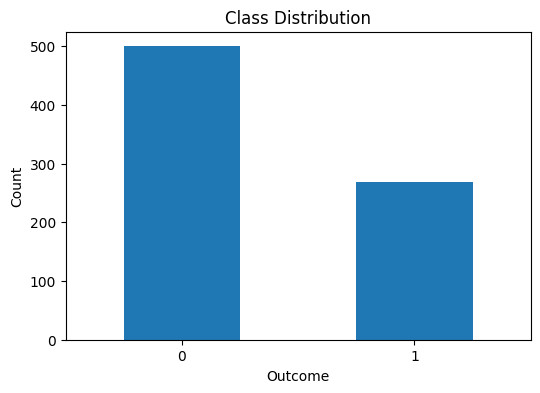

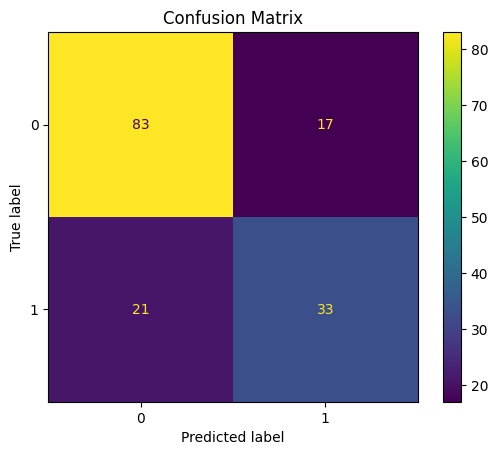

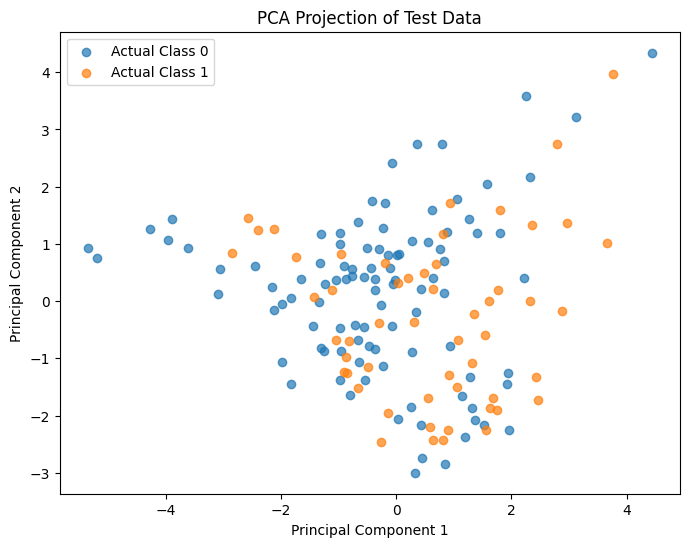

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA

# 1. Load dataset
df = pd.read_csv(r"C:\Users\Nurik\Downloads\diabetes.csv")

# 2. Features and target
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

# 3. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Train SVM
model = SVC(kernel="rbf", C=1.0, gamma="scale")
model.fit(X_train_scaled, y_train)

# 6. Predict
y_pred = model.predict(X_test_scaled)

# 7. Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# -------------------------------
# VISUALIZATION 1: Class count
# -------------------------------
plt.figure(figsize=(6, 4))
df["Outcome"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# -------------------------------
# VISUALIZATION 2: Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# -------------------------------
# VISUALIZATION 3: PCA 2D SVM Visualization
# -------------------------------
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))

for label in [0, 1]:
    plt.scatter(
        X_test_pca[y_test.values == label, 0],
        X_test_pca[y_test.values == label, 1],
        label=f"Actual Class {label}",
        alpha=0.7
    )

plt.title("PCA Projection of Test Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.show()

In [4]:
import pandas as pd

data = {
    "hours_study": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 2, 3, 5, 6, 7],
    "attendance":  [40, 45, 50, 55, 60, 65, 70, 72, 75, 80, 82, 85, 88, 90, 95, 48, 58, 78, 84, 89],
    "assignments": [30, 35, 40, 42, 50, 55, 60, 65, 68, 72, 75, 80, 82, 88, 92, 38, 48, 70, 78, 85],
    "passed":      [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

print(df)

    hours_study  attendance  assignments  passed
0             1          40           30       0
1             2          45           35       0
2             2          50           40       0
3             3          55           42       0
4             3          60           50       0
5             4          65           55       1
6             4          70           60       1
7             5          72           65       1
8             5          75           68       1
9             6          80           72       1
10            6          82           75       1
11            7          85           80       1
12            7          88           82       1
13            8          90           88       1
14            8          95           92       1
15            2          48           38       0
16            3          58           48       0
17            5          78           70       1
18            6          84           78       1
19            7     

Dataset:
    hours_study  attendance  assignments  passed
0             1          40           30       0
1             2          45           35       0
2             2          50           40       0
3             3          55           42       0
4             3          60           50       0
5             4          65           55       1
6             4          70           60       1
7             5          72           65       1
8             5          75           68       1
9             6          80           72       1
10            6          82           75       1
11            7          85           80       1
12            7          88           82       1
13            8          90           88       1
14            8          95           92       1
15            2          48           38       0
16            3          58           48       0
17            5          78           70       1
18            6          84           78       1
19         

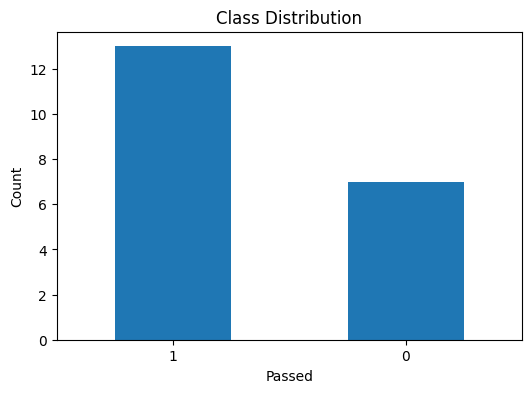

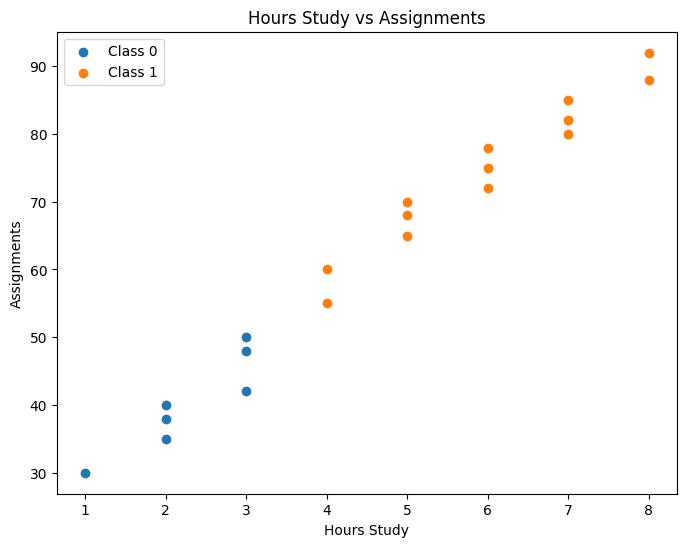

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -----------------------------
# 1. Create dataset
# -----------------------------
data = {
    "hours_study": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 2, 3, 5, 6, 7],
    "attendance":  [40, 45, 50, 55, 60, 65, 70, 72, 75, 80, 82, 85, 88, 90, 95, 48, 58, 78, 84, 89],
    "assignments": [30, 35, 40, 42, 50, 55, 60, 65, 68, 72, 75, 80, 82, 88, 92, 38, 48, 70, 78, 85],
    "passed":      [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

print("Dataset:")
print(df)

# -----------------------------
# 2. Split into X and y
# -----------------------------
X = df[["hours_study", "attendance", "assignments"]]
y = df["passed"]

# -----------------------------
# 3. Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 4. Scaling
# -----------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# 5. Create and train SVM
# -----------------------------
model = SVC(kernel="linear")
model.fit(X_train_scaled, y_train)

# -----------------------------
# 6. Prediction
# -----------------------------
y_pred = model.predict(X_test_scaled)

# -----------------------------
# 7. Evaluation
# -----------------------------
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -----------------------------
# 8. Visualization 1: class distribution
# -----------------------------
plt.figure(figsize=(6, 4))
df["passed"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Passed")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# -----------------------------
# 9. Visualization 2: scatter plot
# -----------------------------
plt.figure(figsize=(8, 6))

for label in [0, 1]:
    subset = df[df["passed"] == label]
    plt.scatter(subset["hours_study"], subset["assignments"], label=f"Class {label}")

plt.xlabel("Hours Study")
plt.ylabel("Assignments")
plt.title("Hours Study vs Assignments")
plt.legend()
plt.show()

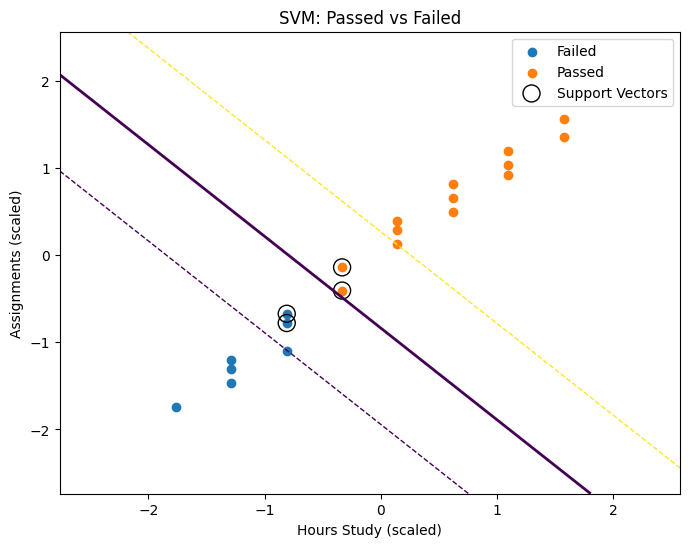

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# 1. Create dataset
data = {
    "hours_study": [1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 2, 3, 5, 6, 7],
    "attendance":  [40, 45, 50, 55, 60, 65, 70, 72, 75, 80, 82, 85, 88, 90, 95, 48, 58, 78, 84, 89],
    "assignments": [30, 35, 40, 42, 50, 55, 60, 65, 68, 72, 75, 80, 82, 88, 92, 38, 48, 70, 78, 85],
    "passed":      [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)

# 2. Use only 2 columns for visualization
X = df[["hours_study", "assignments"]].values
y = df["passed"].values

# 3. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Train SVM
model = SVC(kernel="linear")
model.fit(X_scaled, y)

# 5. Plot points
plt.figure(figsize=(8, 6))

for label in [0, 1]:
    plt.scatter(
        X_scaled[y == label, 0],
        X_scaled[y == label, 1],
        label="Failed" if label == 0 else "Passed"
    )

# 6. Create decision boundary
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 7. Draw separating line and margins
plt.contour(xx, yy, Z, levels=[0], linewidths=2)
plt.contour(xx, yy, Z, levels=[-1, 1], linestyles="dashed", linewidths=1)

# 8. Highlight support vectors
plt.scatter(
    model.support_vectors_[:, 0],
    model.support_vectors_[:, 1],
    s=150,
    facecolors="none",
    edgecolors="k",
    label="Support Vectors"
)

plt.xlabel("Hours Study (scaled)")
plt.ylabel("Assignments (scaled)")
plt.title("SVM: Passed vs Failed")
plt.legend()
plt.show()